In [1]:
    %matplotlib inline


Ensemble LDA
============

Introduces Gensim's EnsembleLda model




In [2]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
import gensim.downloader as api
from gensim.corpora import Dictionary, MmCorpus
import nltk
import pandas as pd
from gensim.models import LdaModel
from gensim.models import EnsembleLda
import string
from sklearn.cluster import KMeans
from sklearn.manifold import Isomap
from scipy.spatial.distance import cdist
import numpy as np
from IPython.core.pylabtools import figsize
import os
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
from pathlib import Path
from sklearn.manifold import Isomap
import pickle
import hdbscan
import umap

prefix = "orzeszkowa_nouns_scan_clyn_teilkorpus"
text_dir = "teilkorpus"

Corpus
------
We will use the gensim downloader api to get a small corpus for training our ensemble.

The preprocessing is similar to `sphx_glr_auto_examples_tutorials_run_word2vec.py`,
so it won't be explained again in detail.




In [3]:
# nltk.download('wordnet')
translator = str.maketrans('', '', string.punctuation)

lemmatizer = nltk.stem.wordnet.WordNetLemmatizer()

docs = []
titles = []
removed = []

for f in sorted(os.listdir(text_dir)):
    with open(os.path.join(text_dir, f)) as fil:
        text = fil.read().split(" ")
        if len(text) >= 300:
            docs.append(text)
            titles.append(f)
        else:
            removed.append(f)

dictionary = Dictionary(docs)
dictionary.filter_extremes(no_below=3, no_above=0.5)
# dictionary.filter_extremes(no_below=10, no_above=0.6)

corpus = [dictionary.doc2bow(doc) for doc in docs]

2026-03-04 22:27:56,448 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-03-04 22:27:56,759 : INFO : built Dictionary<32586 unique tokens: ['abominabl', 'absrude', 'absurde', 'adamaszek', 'adamaszk']...> from 53 documents (total 587113 corpus positions)
2026-03-04 22:27:56,759 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<32586 unique tokens: ['abominabl', 'absrude', 'absurde', 'adamaszek', 'adamaszk']...> from 53 documents (total 587113 corpus positions)", 'datetime': '2026-03-04T22:27:56.759507', 'gensim': '4.4.0', 'python': '3.12.12 (main, Feb  6 2026, 00:00:00) [GCC 15.2.1 20260123 (Red Hat 15.2.1-7)]', 'platform': 'Linux-6.18.13-200.fc43.x86_64-x86_64-with-glibc2.42', 'event': 'created'}
2026-03-04 22:27:56,786 : INFO : discarding 23020 tokens: [('abominabl', 1), ('absrude', 1), ('absurde', 2), ('adaszek', 1), ('adresse', 1), ('aferzysta', 2), ('agat', 2), ('akcjonaryusz', 2), ('akord', 29), ('akt', 29)]...
2026-03-04 22:27:56,786 : INFO : keepin

In [4]:
with open(prefix + "_titles.txt", "w", encoding="utf-8") as file:
    file.write("\n".join(titles) + "\n")

Training
--------

Training the ensemble works very similar to training a single model,

You can use any model that is based on LdaModel, such as LdaMulticore, to train the Ensemble.
In experiments, LdaMulticore showed better results.




In [5]:
topic_model_class = LdaModel

Any arbitrary number of models can be used, but it should be a multiple of your workers so that the
load can be distributed properly. In this example, 4 processes will train 8 models each.




In [6]:
ensemble_workers = 5
num_models = 7 # was 10

After training all the models, some distance computations are required which can take quite some
time as well. You can speed this up by using workers for that as well.




In [7]:
distance_workers = 5

All other parameters that are unknown to EnsembleLda are forwarded to each LDA Model, such as




In [8]:
num_topics = 70 # was 80
passes = 20 # was 50

In [9]:
ensemble = EnsembleLda(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        num_models=num_models,
        topic_model_class=LdaModel,
        ensemble_workers=ensemble_workers,
        distance_workers=distance_workers
    )
ensemble.save(prefix + "_" + str(num_topics) + "_model")
MmCorpus.serialize(prefix  + "_" + str(num_topics) +  "_corpus", corpus)
dictionary.save(prefix  + "_" + str(num_topics) +  "_dict")

2026-03-04 22:28:09,791 : INFO : generating 7 topic models using 5 workers
2026-03-04 22:28:09,821 : INFO : spawned worker to generate 1 topic models
2026-03-04 22:28:09,831 : INFO : using symmetric alpha at 0.014285714285714285
2026-03-04 22:28:09,832 : INFO : spawned worker to generate 1 topic models
2026-03-04 22:28:09,841 : INFO : using symmetric eta at 0.014285714285714285
2026-03-04 22:28:09,842 : INFO : spawned worker to generate 1 topic models
2026-03-04 22:28:09,844 : INFO : using serial LDA version on this node
2026-03-04 22:28:09,842 : INFO : using symmetric alpha at 0.014285714285714285
2026-03-04 22:28:09,853 : INFO : using symmetric alpha at 0.014285714285714285
2026-03-04 22:28:09,852 : INFO : spawned worker to generate 2 topic models
2026-03-04 22:28:09,854 : INFO : using symmetric eta at 0.014285714285714285
2026-03-04 22:28:09,851 : INFO : using symmetric eta at 0.014285714285714285
2026-03-04 22:28:09,855 : INFO : using symmetric alpha at 0.014285714285714285
2026-03

Now start the training

Since 20 topics were trained on each of the 8 models, we expect there to be 160 different topics.
The number of stable topics which are clustered from all those topics is smaller.




In [ ]:
#topic_range = range(65,85,5)
topic_range = [75]
coherence_scores = []
num_tops = []

for num_topics in topic_range:
    ensemble = EnsembleLda(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        num_models=num_models,
        topic_model_class=LdaModel,
        ensemble_workers=ensemble_workers,
        distance_workers=distance_workers
    )

    # topic coherence
    from gensim.models import CoherenceModel
    
    coherence_model = CoherenceModel(
        model=ensemble,
        texts=docs,             # preprocessed texts
        dictionary=dictionary,
        coherence='u_mass'          # u_mass during search, 'c_v' for final
    )
    
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    num_tops.append(len(ensemble.get_topics()))
    print(f"Coherence Score: {coherence_score:.4f} with {num_topics} topics ({len(ensemble.get_topics())} actual topics)")

    ensemble.save(prefix + "_" + str(num_topics) + "_model")
    MmCorpus.serialize(prefix  + "_" + str(num_topics) +  "_corpus", corpus)
    dictionary.save(prefix  + "_" + str(num_topics) +  "_dict")

plt.figure(figsize=(8, 5))
plt.plot(list(topic_range), coherence_scores,  marker="o")
plt.plot(list(topic_range), num_tops, marker="x")
plt.title("Topic Coherence by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence (c_v)")
plt.grid(True)
plt.tight_layout()
plt.show()

2026-02-19 16:21:36,405 : INFO : generating 10 topic models using 5 workers
2026-02-19 16:21:36,453 : INFO : spawned worker to generate 2 topic models
2026-02-19 16:21:36,484 : INFO : using symmetric alpha at 0.013333333333333334
2026-02-19 16:21:36,488 : INFO : spawned worker to generate 2 topic models
2026-02-19 16:21:36,515 : INFO : using symmetric eta at 0.013333333333333334
2026-02-19 16:21:36,517 : INFO : spawned worker to generate 2 topic models
2026-02-19 16:21:36,520 : INFO : using symmetric alpha at 0.013333333333333334
2026-02-19 16:21:36,528 : INFO : using symmetric eta at 0.013333333333333334
2026-02-19 16:21:36,529 : INFO : using symmetric alpha at 0.013333333333333334
2026-02-19 16:21:36,528 : INFO : using serial LDA version on this node
2026-02-19 16:21:36,551 : INFO : using symmetric eta at 0.013333333333333334
2026-02-19 16:21:36,553 : INFO : spawned worker to generate 2 topic models
2026-02-19 16:21:36,557 : INFO : using serial LDA version on this node
2026-02-19 16:

In [40]:
prefix = "orzeszkowa_nouns_scan_clyn_chunfiltered_110"

Tuning
------

Different from LdaModel, the number of resulting topics varies greatly depending on the clustering parameters.

You can provide those in the ``recluster()`` function or the ``EnsembleLda`` constructor.

Play around until you get as many topics as you desire, which however may reduce their quality.
If your ensemble doesn't have enough topics to begin with, you should make sure to make it large enough.

Having an epsilon that is smaller than the smallest distance doesn't make sense.
Make sure to chose one that is within the range of values in ``asymmetric_distance_matrix``.




In [41]:
def chunk_documents_with_titles(docs, titles, chunk_size):
    """
    Returns:
        chunks: list of token lists
        chunk_titles: list of title strings for each chunk
        metadata: list of tuples (original_doc_index, chunk_index)
    """
    chunks = []
    chunk_titles = []
    metadata = []
    for doc_idx, tokens in enumerate(docs):
        doc_title = titles[doc_idx]
        if len(tokens) <= chunk_size:
            chunks.append(tokens)
            chunk_titles.append(doc_title)
            metadata.append((doc_idx, 0))
        else:
            for i, start in enumerate(range(0, len(tokens), chunk_size)):
                chunk = tokens[start:start + chunk_size]
                chunks.append(chunk)
                chunk_titles.append(f"{doc_title} (chunk {i+1})")
                metadata.append((doc_idx, i))
    return chunks, chunk_titles, metadata

# prefix = "orzeszkowa_nouns_scan_clyn_chunked"
text_dir = "literarische_texte_nouns_only_clyn"

# nltk.download('wordnet')
translator = str.maketrans('', '', string.punctuation)

lemmatizer = nltk.stem.wordnet.WordNetLemmatizer()

docs = []
titles = []
removed = []

for f in sorted(os.listdir(text_dir)):
    with open(os.path.join(text_dir, f)) as fil:
        text = fil.read().split(" ")
        docs.append(text)
        titles.append(f)
        
print("Pre-chunk: ", len(docs), np.mean([len(doc) for doc in docs]), np.min([len(doc) for doc in docs]), np.max([len(doc) for doc in docs]))

chunks, chunk_titles, metadata = chunk_documents_with_titles(docs, titles, chunk_size=1100)

print("Post-chunk: ", len(chunks), np.mean([len(chunk) for chunk in chunks]), np.min([len(chunk) for chunk in chunks]), np.max([len(chunk) for chunk in chunks]))

filtered_chunks = []
filtered_titles = []

for chunk, title in zip(chunks, chunk_titles):
    if len(chunk) >= 300:
        filtered_chunks.append(chunk)
        filtered_titles.append(title)

# replace original lists if you want
chunks = filtered_chunks
chunk_titles = filtered_titles

print("Post-filtering: ", len(chunks), np.mean([len(chunk) for chunk in chunks]), np.min([len(chunk) for chunk in chunks]), np.max([len(chunk) for chunk in chunks]))

Pre-chunk:  154 5733.935064935065 47 56046
Post-chunk:  878 1005.7243735763097 8 1100
Post-filtering:  836 1048.0885167464114 305 1100


2026-02-20 09:25:34,326 : INFO : fitting the clustering model


3.92879866972784e-07 0.809158273674302 1.0


2026-02-20 09:25:34,595 : INFO : generating stable topics
2026-02-20 09:25:34,596 : INFO : found 13 clusters
2026-02-20 09:25:34,603 : INFO : found 10 stable topics
2026-02-20 09:25:34,604 : INFO : generating classic gensim model representation based on results from the ensemble
2026-02-20 09:25:34,605 : INFO : using symmetric alpha at 0.1
2026-02-20 09:25:34,605 : INFO : using symmetric eta at 0.1
2026-02-20 09:25:34,609 : INFO : using serial LDA version on this node
2026-02-20 09:25:34,626 : INFO : running online (multi-pass) LDA training, 10 topics, 0 passes over the supplied corpus of 836 documents, updating model once every 836 documents, evaluating perplexity every 836 documents, iterating 50x with a convergence threshold of 0.001000
2026-02-20 09:25:34,627 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-02-20 09:25:34,628 : INFO : LdaModel lifecycle event {'msg': 'trained LdaModel<num_terms

Coherence Score: 0.5025 for epsilon=0.11 (10 topics)


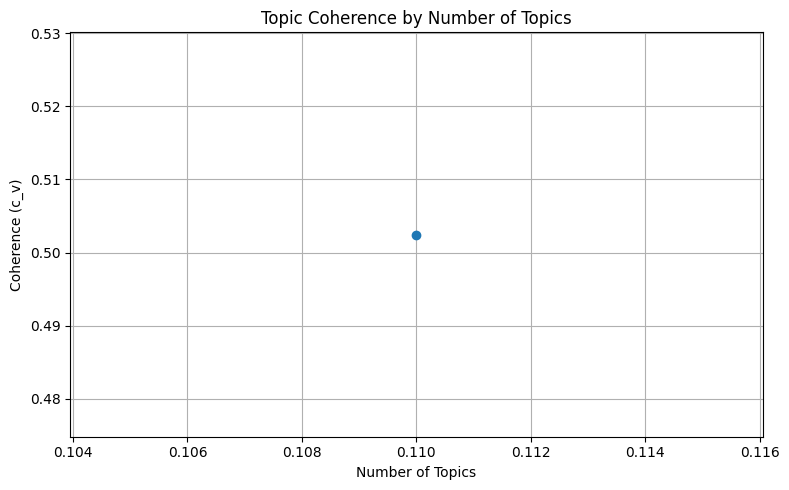

In [50]:
import numpy as np
coherence_scores = []
epsilon_range =  [x / 100.0 for x in range(1, 50, 2)]
epsilon_range = [0.11] 

for e in epsilon_range:
    shape = ensemble.asymmetric_distance_matrix.shape
    without_diagonal = ensemble.asymmetric_distance_matrix[~np.eye(shape[0], dtype=bool)].reshape(shape[0], -1)
    print(without_diagonal.min(), without_diagonal.mean(), without_diagonal.max())

    ensemble.recluster(eps=e, min_samples=2, min_cores=2)

    # topic coherence   
    from gensim.models import CoherenceModel
    
    coherence_model = CoherenceModel(
        model=ensemble,
        texts=docs,             # preprocessed texts
        dictionary=dictionary,
        coherence='c_v'          # or 'c_npmi', 'u_mass', etc.
    )
    
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"Coherence Score: {coherence_score:.4f} for epsilon={e} ({len(ensemble.get_topics())} topics)")


plt.figure(figsize=(8, 5))
plt.plot(list(epsilon_range), coherence_scores, marker="o")
plt.title("Topic Coherence by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence (c_v)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# sanity check
vecs = np.zeros((len(corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob
dominant = np.argmax(vecs, axis=1)
np.bincount(dominant)

array([ 98,  85, 234,  55, 171,  18, 132,  15,  25,   3])

In [82]:
import numpy as np

topics = ensemble.get_topics()

topn = 30

for topic_id in range(10):
    top_word_indices = topics[topic_id].argsort()[-topn:][::-1]
    print("Topic", topic_id)
    for i in top_word_indices:
        print(dictionary[i], topics[topic_id][i])



Topic 0
salon 6.761299467446709e-05
siostra 6.739876577436614e-05
hrabia 6.696374005817536e-05
las 6.687977308198849e-05
ulica 6.68602356199699e-05
izba 6.685307077229179e-05
ogród 6.682179825171868e-05
mama 6.673666909288538e-05
koń 6.664672067320983e-05
pieniądz 6.658886271300919e-05
chata 6.65145098537323e-05
sala 6.631544298822216e-05
rodzina 6.631385485889041e-05
państwo 6.631269904270691e-05
towarzystwo 6.629915499919055e-05
umysł 6.628164495244467e-05
plecy 6.62151299669252e-05
muzyka 6.617457908456952e-05
krzesło 6.615694580129154e-05
interes 6.615526793514921e-05
papier 6.614935076261948e-05
brzeg 6.613344612560468e-05
przyjaciel 6.60708237774088e-05
lampa 6.606959201841771e-05
mię 6.60555583635869e-05
wrażenie 6.605023433318517e-05
przyszłość 6.603384978613273e-05
list 6.603036354135838e-05
chleb 6.60143944818022e-05
nauka 6.60103097895141e-05
Topic 1
doktor 0.10800916754773685
muzyka 0.008598471825410212
umysł 0.00539000759766038
salon 0.005238335380064589
pacjent 0.00504394

In [49]:
dominant = np.argmax(vecs, axis=1)

import numpy as np

avg_lengths = []
for t in range(len(np.bincount(dominant))):
    avg_lengths.append(np.mean(np.array(lengths)[dominant == t]))

for i, l in enumerate(avg_lengths):
    print(i, l)


0 303.0
1 427.8888888888889
2 419.45454545454544
3 416.3076923076923
4 413.3247863247863
5 385.1
6 432.8965517241379
7 423.22222222222223
8 386.77272727272725
9 424.0
10 412.36538461538464
11 345.0
12 439.25155925155923
13 426.75
14 416.3333333333333


In [56]:
import numpy as np
from collections import Counter, defaultdict

# Example: dominant = np.array([...])
# chunk_titles = np.array([...])

# Step 1: Extract genre ('P' or 'N') from filenames
genres = np.array(['P' if '_P.' in t else 'N' for t in chunk_titles])

# Step 2: Count topics by genre
topic_counts_by_genre = defaultdict(lambda: {'P': 0, 'N': 0})

for topic, genre in zip(dominant, genres):
    topic_counts_by_genre[topic][genre] += 1

# Step 3: Compute percentages
topic_percent_by_genre = {}
for topic, counts in topic_counts_by_genre.items():
    total = counts['P'] + counts['N']
    topic_percent_by_genre[topic] = {
        'P': counts['P'] / total,
        'N': counts['N'] / total,
        'total_chunks': total
    }

# Step 4: Print sorted results
for topic, stats in sorted(topic_percent_by_genre.items()):
    print(f"Topic {topic}: P {stats['P']:.2f}, N {stats['N']:.2f}, chunks {stats['total_chunks']}")


Topic 0: P 0.69, N 0.31, chunks 98
Topic 1: P 0.75, N 0.25, chunks 85
Topic 2: P 0.84, N 0.16, chunks 234
Topic 3: P 0.95, N 0.05, chunks 55
Topic 4: P 0.65, N 0.35, chunks 171
Topic 5: P 0.39, N 0.61, chunks 18
Topic 6: P 0.41, N 0.59, chunks 132
Topic 7: P 0.27, N 0.73, chunks 15
Topic 8: P 0.96, N 0.04, chunks 25
Topic 9: P 1.00, N 0.00, chunks 3


## Save stuff

In [65]:
# save the stuffEnsembleLda.load(temp_file)
with open(prefix + "_titles.txt", "w", encoding="utf-8") as file:
    file.write("\n".join(titles) + "\n")
with open(prefix + "_chunk_titles.txt", "w", encoding="utf-8") as file:
    file.write("\n".join(chunk_titles) + "\n")
ensemble.save(prefix + "_model")
MmCorpus.serialize(prefix + "_corpus", corpus)
dictionary.save(prefix + "_dict")

2026-02-20 09:43:42,954 : INFO : EnsembleLda lifecycle event {'fname_or_handle': 'orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset({'topic_model_class'}), 'datetime': '2026-02-20T09:43:42.954015', 'gensim': '4.4.0', 'python': '3.12.12 (main, Jan 16 2026, 00:00:00) [GCC 15.2.1 20251211 (Red Hat 15.2.1-5)]', 'platform': 'Linux-6.18.10-200.fc43.x86_64-x86_64-with-glibc2.42', 'event': 'saving'}
2026-02-20 09:43:42,954 : INFO : storing np array 'ttda' to orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model.ttda.npy
2026-02-20 09:43:43,136 : INFO : not storing attribute topic_model_class
2026-02-20 09:43:43,261 : INFO : saved orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model
2026-02-20 09:43:43,262 : INFO : storing corpus in Matrix Market format to orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_corpus
2026-02-20 09:43:43,263 : INFO : saving sparse matrix to orzeszkowa_eps_0-11_110_10_topics_chunfilt

In [3]:
prefix = "orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn"

Apply Topic Model
-----------------

In [4]:
ensemble = EnsembleLda.load(prefix + "_model")
dictionary = Dictionary.load(prefix + "_dict")
corpus = MmCorpus(prefix + "_corpus")
with open(prefix + "_titles.txt", "r", encoding="utf-8") as file:
    titles = file.read().split("\n")
with open(prefix + "_chunk_titles.txt", "r", encoding="utf-8") as file:
    chunk_titles = file.read().split("\n")

print(titles)
print(len(ensemble.get_topics()))
ensemble.print_topics(60,20)

2026-02-25 12:57:13,023 : INFO : loading EnsembleLda object from orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model
2026-02-25 12:57:13,109 : INFO : loading classic_model_representation recursively from orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model.classic_model_representation.* with mmap=None
2026-02-25 12:57:13,110 : INFO : loading id2word recursively from orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model.classic_model_representation.id2word.* with mmap=None
2026-02-25 12:57:13,111 : INFO : loading state recursively from orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model.classic_model_representation.state.* with mmap=None
2026-02-25 12:57:13,112 : INFO : loading ttda from orzeszkowa_eps_0-11_110_10_topics_chunfiltered_clyn_model.ttda.npy with mmap=None
2026-02-25 12:57:13,247 : INFO : setting ignored attribute topic_model_class to None
2026-02-25 12:57:13,248 : INFO : EnsembleLda lifecycle event {'fname': 'orzeszkowa_eps_0-11_110_10_topics_chunfilter

['A..._B..._C..._1884_N.txt', 'Ad_astra_Dwugłos_1902_P.txt', 'Anastazja_1900_P.txt', 'Ani_kawałeczka!_1890_N.txt', 'Anioły_1886.txt', 'Ardelion_1883_P.txt', 'Argonauci_1898_P.txt', 'Ascetka_1890_N.txt', 'Asylum_1885_N.txt', 'Australczyk_1894_P.txt', 'Babunia_1894_N.txt', 'Bańka_mydlana_1882_N.txt', 'Baśń_1888_B.txt', 'Bene_nati_1891_P.txt', 'Bez_duszy_1886_N.txt', 'Bracia_1894_N.txt', 'Bóg_wie_kto_1908_N.txt', 'Cham_1888_P.txt', 'Chochlik-Psotnik_1891_N.txt', 'Cień_1902_N.txt', 'Cnotliwi_1869_P.txt', 'Co_mówił_stary_klon_1897_N.txt', 'Czciciel_Potęgi_1889_N.txt', 'Czego_po_świecie_szukał_smutek_1888_B.txt', 'Czternasta_część_1878_N.txt', 'Czy_pamiętasz_1889_N.txt', 'Daj_kwiatek_1877_N.txt', 'Daleko_1890_N.txt', 'Dobra_pani_1882_N.txt', 'Dwa_bieguny_1892_P.txt', 'Dwie_1901_N.txt', 'Dymy_1899_N.txt', 'Dziurdziowie_1885_P.txt', 'Dziwak_1875_N.txt', 'Dziwna_historia_1904_N.txt', 'Echo_1886_N.txt', 'Eli_Makower_1874_P.txt', 'Excelsior!_1897_N.txt', 'Gdzie_szczęście_1890_N.txt', 'Gedali_1884

[(0,
  '0.000*"salon" + 0.000*"siostra" + 0.000*"hrabia" + 0.000*"las" + 0.000*"ulica" + 0.000*"izba" + 0.000*"ogród" + 0.000*"mama" + 0.000*"koń" + 0.000*"pieniądz" + 0.000*"chata" + 0.000*"sala" + 0.000*"rodzina" + 0.000*"państwo" + 0.000*"towarzystwo" + 0.000*"umysł" + 0.000*"plecy" + 0.000*"muzyka" + 0.000*"krzesło" + 0.000*"interes"'),
 (1,
  '0.108*"doktor" + 0.009*"muzyka" + 0.005*"umysł" + 0.005*"salon" + 0.005*"pacjent" + 0.005*"sztuka" + 0.005*"gabinet" + 0.004*"ulica" + 0.004*"fortepian" + 0.004*"ton" + 0.004*"charakter" + 0.004*"towarzystwo" + 0.004*"przyjaciel" + 0.004*"wesołość" + 0.003*"medycyna" + 0.003*"artysta" + 0.003*"piękność" + 0.003*"zawód" + 0.003*"salonik" + 0.003*"państwo"'),
 (2,
  '0.084*"hrabia" + 0.022*"hrabina" + 0.015*"hrabio" + 0.009*"hrabiy" + 0.007*"rodzina" + 0.005*"pałac" + 0.004*"fotel" + 0.004*"salon" + 0.004*"list" + 0.004*"umysł" + 0.004*"stryj" + 0.003*"państwo" + 0.003*"komnata" + 0.003*"źrenica" + 0.003*"towarzystwo" + 0.003*"wzruszenie" + 0.

In [7]:
# use orginal corpus instead of reuniting chunks
original_corpus = []

for f in sorted(os.listdir(text_dir)):
    with open(os.path.join(text_dir, f)) as fil:
        text = fil.read().split(" ")
        original_corpus.append(dictionary.doc2bow(text))

          
# topic distributions for each document
vecs = np.zeros((len(original_corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(original_corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob

# get dominant topics
dominant = np.argmax(vecs, axis=1)
print(np.bincount(dominant))

vecs_hell = np.sqrt(vecs)

clusters = np.argmax(vecs, axis=1)  # shape (n_docs,) DOMINANT TOPCIS

import umap

umap_model = umap.UMAP(
    n_neighbors=12,     # was: 25 ~15% of corpus → stable
    min_dist=0.05,      # was: 0.15 allows separation but keeps gradients
    n_components=2,
    metric="euclidean", # is hellinger for vecs_hell = np.sqrt(vecs) 
    random_state=42
)

coords = umap_model.fit_transform(vecs_hell)

with open(prefix+"_coords.pkl", 'wb') as f:
    pickle.dump(coords, f)

dominant_topics = np.argmax(vecs, axis=1)
import plotly.express as px
import plotly.io as pio
fig = px.scatter(x=coords[:,0], y=coords[:,1],  hover_name=titles,color=clusters, size=lengths,  width=1200, height=1000, color_continuous_scale=px.colors.qualitative.Vivid)
pio.renderers.default = "browser"
fig.show()
#fig.write_html(prefix+".html")
#pio.write_image(fig, prefix+'.pdf', scale=6, width=1080, height=1080)
        

[24  9 21  2 36  4 54  3  1]


/home/ghowa/habil/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Opening in existing browser session.


/home/ghowa/habil/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



NameError: name 'adjust_text' is not defined

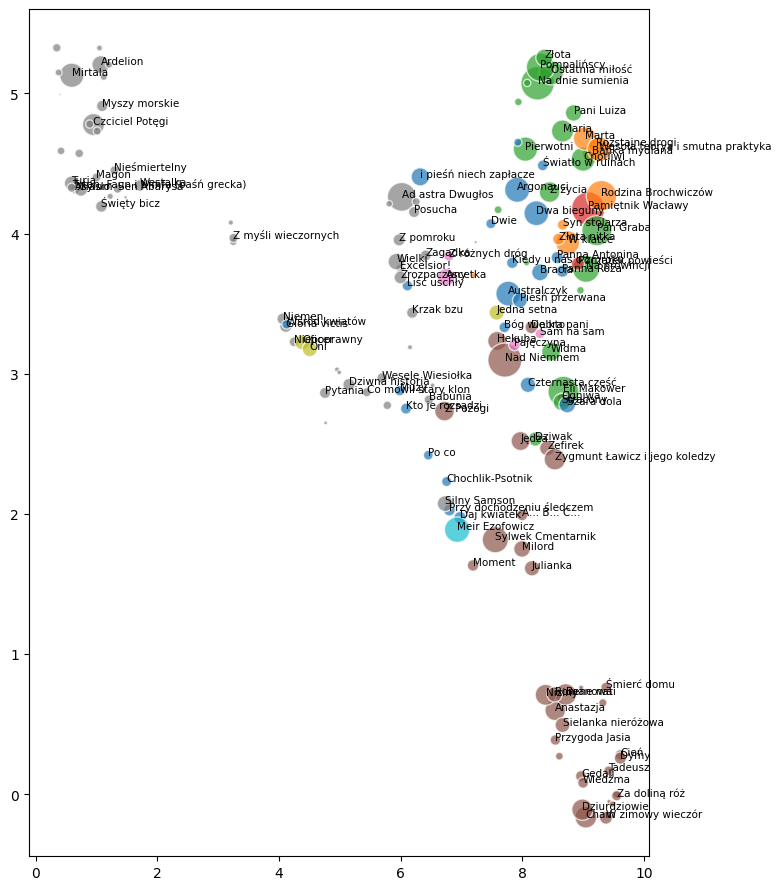

In [8]:
# print-ready layout

import matplotlib.patches as mpatches
# --- assume original_corpus, vecs, vecs_hell, clusters, titles are already prepared ---

# Fit UMAP preserving local distances as much as possible
umap_model = umap.UMAP(
    n_neighbors=12,    # small → local neighborhoods
    min_dist=0.025,      # preserve exact local distances
    n_components=2,
    metric="euclidean",
    random_state=42
)
coords = umap_model.fit_transform(vecs_hell)

# --- Plot for print using matplotlib + adjustText ---
plt.figure(figsize=(8, 11))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=clusters,             # color by dominant topic,
    cmap=plt.get_cmap('tab10'),            # up to 20 topics
    s=[len(b)/10 for b in original_corpus],#np.clip(np.array([len(b) for b in original_corpus]), 5, 100),  # size proportional to doc length
    alpha=0.7,
    edgecolors='white'
)

# Annotate points with titles (abbreviated for readability)
labels = []
for i, title in enumerate(titles):
    if len(original_corpus[i]) >= 400:
        labels.append(title)  # show label
    else:
        labels.append("")     # empty string → no label

texts = []
for i, title in enumerate(labels):
    # Abbreviate long titles for print
    short_title = " ".join(title.split("_")[:-2])
    texts.append(plt.text(coords[i, 0], coords[i, 1], short_title, fontsize=7.5))

# Adjust text labels to prevent overlap
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.2, 1.2),   # push labels further apart
    expand_points=(1.2, 1.2),
    force_text=0.5,
    force_points=0.5
)

# Remove ticks
ax = plt.gca()
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Add top-left legend
cmap = plt.get_cmap('tab10')
num_topics = len(np.unique(clusters))
topic_labels = [
    'Bourgeoisie',
    'Intelligenzija',
    'Aristokratie',
    'Häusliches',
    'Bauern',
    'Christentum',
    'Historisches',
    'Militär',
    'Judentum',
    'Kapital'
]
handles = [mpatches.Patch(color=cmap(i), label=topic_labels[i]) for i in range(num_topics)]
plt.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.7, borderpad=0.3)

plt.tight_layout()
plt.savefig(prefix+"_umap_print.png", dpi=600)
plt.show()

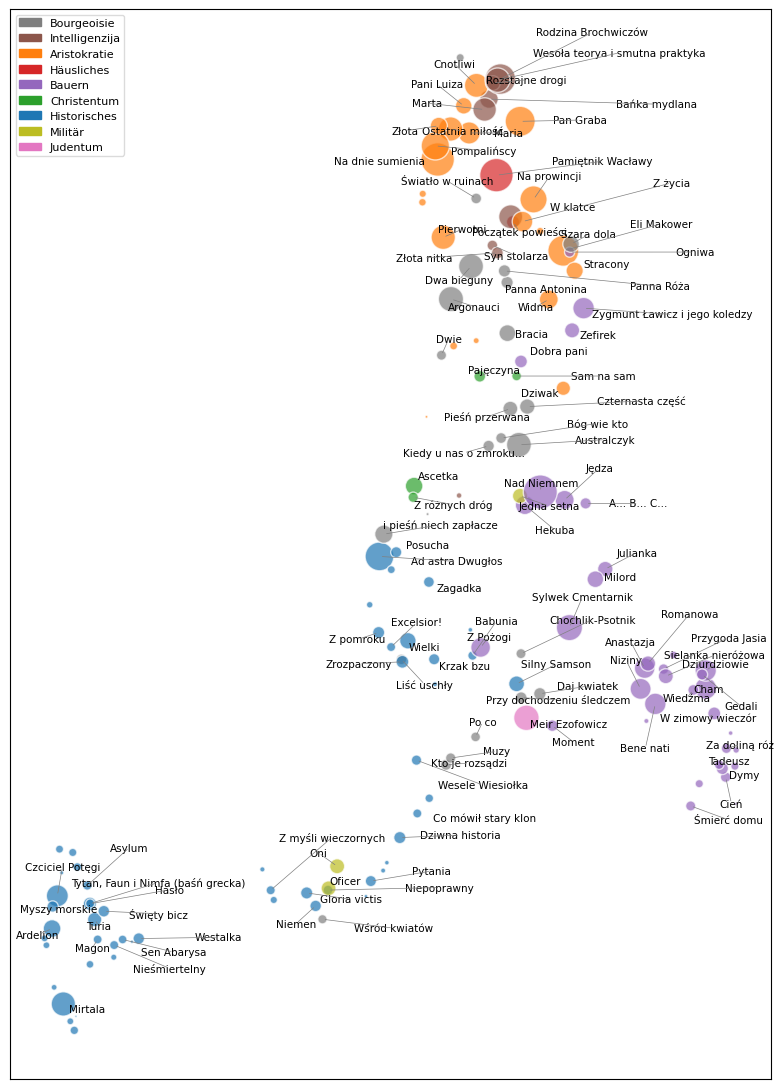

In [115]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from adjustText import adjust_text
import numpy as np
import umap
import random

# --- assume original_corpus, vecs_hell, clusters, titles are already prepared ---

plt.figure(figsize=(8, 11))

num_topics = len(np.unique(clusters))

# Get standard colormap colors and shuffle them
cmap = plt.get_cmap('tab10')
colors_list = [cmap(i) for i in range(num_topics)]
random.seed(0)
random.shuffle(colors_list)

# Map cluster indices to colors
topic_colors = {i: colors_list[i] for i in range(num_topics)}
colors = [topic_colors[cluster] for cluster in clusters]

scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=colors,
    s=[len(b)/10 for b in original_corpus],
    alpha=0.7,
    edgecolors='white'
)

# Annotate points
labels = [title if len(original_corpus[i]) >= 400 else "" for i, title in enumerate(titles)]

texts = []
for i, title in enumerate(labels):
    if title:
        short_title = " ".join(title.split("_")[:-2])
        texts.append(plt.text(coords[i, 0], coords[i, 1], short_title, fontsize=7.5))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2),
    force_text=0.5,
    force_points=0.5
)

# Remove ticks
ax = plt.gca()
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Legend
topic_labels = [
    'Bourgeoisie', 'Intelligenzija', 'Aristokratie', 'Häusliches', 
    'Bauern', 'Christentum', 'Historisches', 'Militär', 
    'Judentum', 'Kapital'
]
handles = [mpatches.Patch(color=topic_colors[i], label=topic_labels[i]) for i in range(num_topics)]
plt.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.7, borderpad=0.3)

plt.tight_layout()
plt.savefig(prefix+"_umap_print_shuffled_colors.png", dpi=600)
plt.show()


In [66]:
# top 5 topics
top_n = 5  # how many top texts per topic

n_topics = vecs.shape[1]

top_texts = {}

for t in range(n_topics):
    topic_probs = vecs[:, t]  # probability of topic t in each document
    
    # sort indices by probability descending
    top_indices = np.argsort(topic_probs)[::-1][:top_n]
    
    top_texts[t] = [(titles[i], topic_probs[i]) for i in top_indices]

# Print results
for t, docs in top_texts.items():
    print(f"\nTopic {t}")
    for title, prob in docs:
        print(f"{title}  ({prob:.3f})")



Topic 0
Wśród_kwiatów_1895_N.txt  (0.324)
Kwiat_i_kobieta_1866_W.txt  (0.320)
„Pokociło_się”_i_„Dam_nogę”_1880_K.txt  (0.311)
Excelsior!_1897_N.txt  (0.301)
Muzy_1888_N.txt  (0.299)

Topic 1
Wesoła_teorya_i_smutna_praktyka_1872_P.txt  (0.832)
Rozstajne_drogi_1866_Op.txt  (0.385)
Anioły_1886.txt  (0.309)
Marta_1873_P.txt  (0.306)
Złota_nitka_1881_N.txt  (0.282)

Topic 2
Pani_Dutkowa_1907_N.txt  (0.800)
Pompalińscy_1875_P.txt  (0.690)
Kariery_1890_N.txt  (0.626)
Złota_hrabinka_1877.txt  (0.574)
Na_dnie_sumienia_1872_P.txt  (0.501)

Topic 3
Pamiętnik_Wacławy_1870_P.txt  (0.425)
Kwiat_i_kobieta_1866_W.txt  (0.317)
Początek_powieści_1866_N.txt  (0.286)
Siteczko_1891_N.txt  (0.201)
Syn_stolarza_1868_Op.txt  (0.195)

Topic 4
Dziurdziowie_1885_P.txt  (0.840)
Cham_1888_P.txt  (0.826)
W_zimowy_wieczór_1887_Op.txt  (0.729)
Obrazek_z_lat_głodowych_1866_N.txt  (0.688)
Wiedźma_1888_N.txt  (0.672)

Topic 5
Ascetka_1890_N.txt  (0.842)
Z_różnych_dróg_1899_N.txt  (0.556)
Tęsknota_1866_W.txt  (0.258)
Pa

Topic Ranking (Highest → Lowest):

1. Aristokratie: 0.177530
2. Bourgeoisie: 0.165681
3. Historisches: 0.151581
4. Bauern: 0.147618
5. Intelligenzija: 0.117275
6. Häusliches: 0.088417
7. Christentum: 0.060499
8. Militär: 0.037198
9. Judentum: 0.026598
10. Kapital: 0.021260


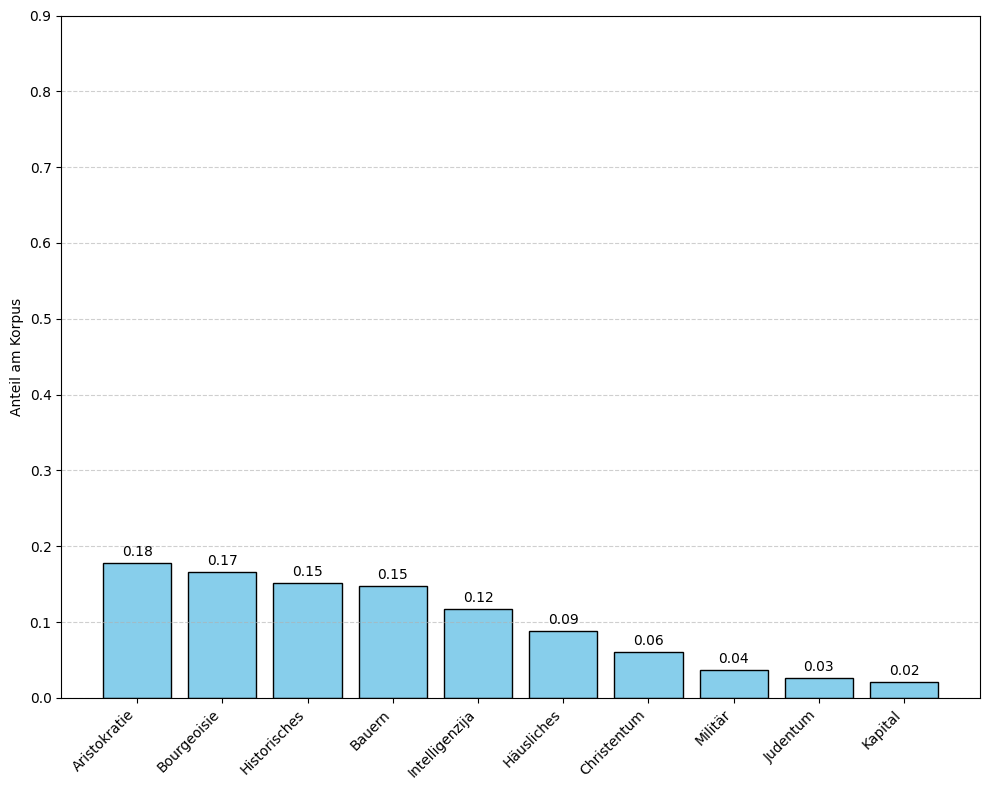

In [72]:
## Topic distribution for corpus
topic_sums = np.zeros(10)
total_words = 0

for bow in original_corpus:
    doc_length = sum(cnt for _, cnt in bow)
    total_words += doc_length

    for topic, prob in ensemble[bow]:
        topic_sums[topic] += prob * doc_length

corpus_topic_distribution = topic_sums / total_words

# ---- Ranking ----
sorted_indices = np.argsort(-corpus_topic_distribution)
sorted_values = corpus_topic_distribution[sorted_indices]
sorted_labels = [topic_labels[i] for i in sorted_indices]

print("Topic Ranking (Highest → Lowest):\n")
for rank, (label, value) in enumerate(zip(sorted_labels, sorted_values), start=1):
    print(f"{rank}. {label}: {value:.6f}")

# ---- Plot ----
plt.figure(figsize=(10,8))
plt.bar(range(len(sorted_values)), sorted_values, color="skyblue", edgecolor="black")

plt.ylabel("Anteil am Korpus")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 0.9)

# Optional: show values on top of bars
for i, val in enumerate(sorted_values):
    plt.text(i, val + 0.005, f"{val:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(prefix + "_corpus_topics.png", dpi=600)
plt.show()

1866
Counter({'1889–': 73, '1878–1888': 50, '1866–1877': 31})


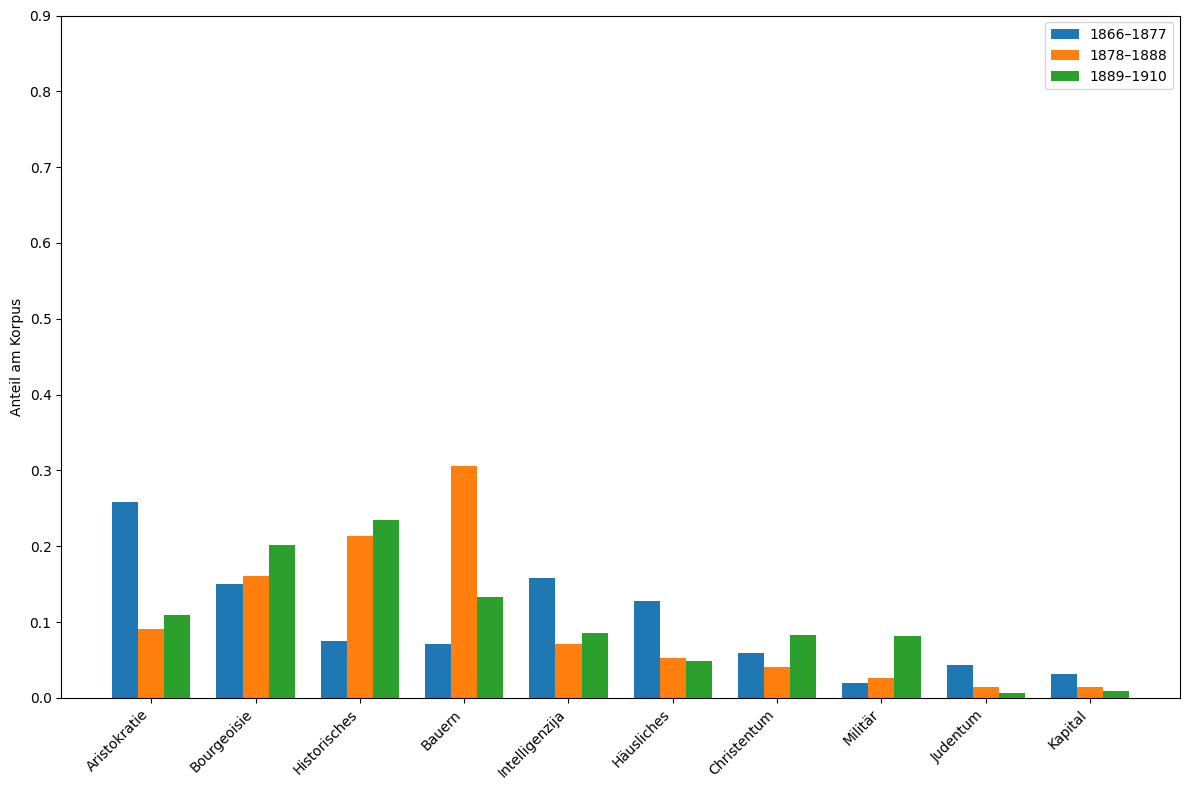

In [81]:
# topic distribution mit zeitschnitt
import re

years = []

for title in titles:
    match = re.search(r"_(\d{4})", title)
    if match:
        years.append(int(match.group(1)))
    else:
        years.append(None)
       
def assign_period(year):
    if year is None:
        return None
    elif 1865 <= year <= 1877:
        return "1866–1877"
    elif 1878 <= year <= 1888:
        return "1878–1888"
    elif year >= 1889:
        return "1889–"
    else:
        return None

periods = [assign_period(y) for y in years]

from collections import Counter
print(Counter(periods))

n_topics = 10

period_topic_sums = {
    "1866–1877": np.zeros(n_topics),
    "1878–1888": np.zeros(n_topics),
    "1889–": np.zeros(n_topics)
}

period_word_totals = {
    "1866–1877": 0,
    "1878–1888": 0,
    "1889–": 0
}

for i, bow in enumerate(original_corpus):
    period = periods[i]
    if period is None:
        continue

    doc_length = sum(cnt for _, cnt in bow)
    period_word_totals[period] += doc_length

    for topic, prob in ensemble[bow]:
        period_topic_sums[period][topic] += prob * doc_length

# Normalize
period_distributions = {}

for p in period_topic_sums:
    period_distributions[p] = (
        period_topic_sums[p] / period_word_totals[p]
    )

plt.figure(figsize=(12,8))

x = np.arange(n_topics)
width = 0.25

plt.bar(x - width, dist_1, 
        width=width, label="1866–1877")

plt.bar(x, dist_2, 
        width=width, label="1878–1888")

plt.bar(x + width, dist_3, 
        width=width, label="1889–1910")

plt.xticks(x, sorted_labels, rotation=45, ha="right")
plt.ylabel("Anteil am Korpus")
plt.legend()
plt.ylim(0, 0.9)


plt.tight_layout()
plt.savefig(prefix + "_corpus_topics_period.png", dpi=600)
plt.show()

Counter({'1878–1888': 50, '1889–1899': 41, '1900–1910': 32, '1866–1877': 31})


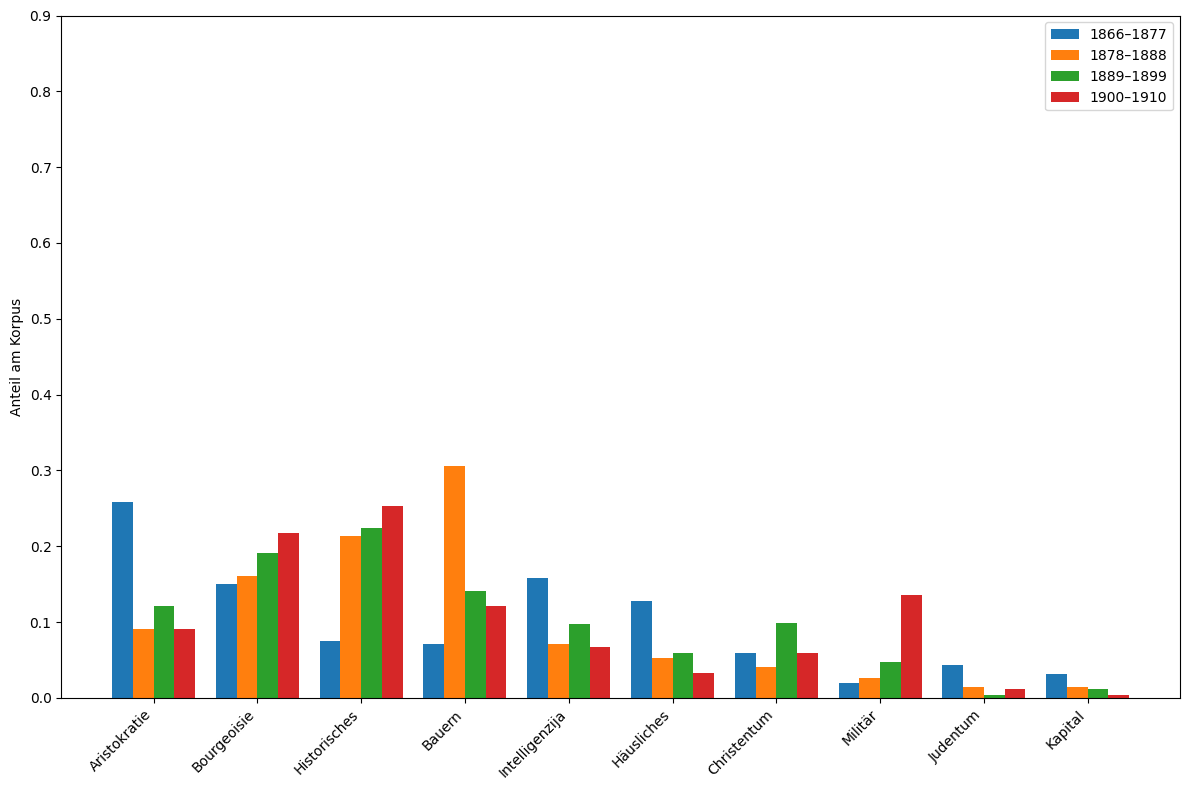

In [87]:
# topic distribution mit zeitschnitt/4
import re

years = []

for title in titles:
    match = re.search(r"_(\d{4})", title)
    if match:
        years.append(int(match.group(1)))
    else:
        years.append(None)
       
def assign_period(year):
    if year is None:
        return None
    elif 1865 <= year <= 1877:
        return "1866–1877"
    elif 1878 <= year <= 1888:
        return "1878–1888"
    elif 1889 <= year <= 1899:        
        return "1889–1899"
    elif year >= 1900:        
        return "1900–1910"
    else:
        return None

periods = [assign_period(y) for y in years]

from collections import Counter
print(Counter(periods))

n_topics = 10

period_topic_sums = {
    "1866–1877": np.zeros(n_topics),
    "1878–1888": np.zeros(n_topics),
    "1889–1899": np.zeros(n_topics),
    "1900–1910": np.zeros(n_topics)
}

period_word_totals = {
    "1866–1877": 0,
    "1878–1888": 0,
    "1889–1899": 0,
    "1900–1910": 0,
}

for i, bow in enumerate(original_corpus):
    period = periods[i]
    if period is None:
        continue

    doc_length = sum(cnt for _, cnt in bow)
    period_word_totals[period] += doc_length

    for topic, prob in ensemble[bow]:
        period_topic_sums[period][topic] += prob * doc_length

dist_1 = period_distributions["1866–1877"][sorted_indices]
dist_2 = period_distributions["1878–1888"][sorted_indices]
dist_3 = period_distributions["1889–1899"][sorted_indices]
dist_4 = period_distributions["1900–1910"][sorted_indices]

# Normalize
period_distributions = {}

for p in period_topic_sums:
    period_distributions[p] = (
        period_topic_sums[p] / period_word_totals[p]
    )

plt.figure(figsize=(12,8))

x = np.arange(n_topics)
width = 0.2

plt.bar(x - 1.5*width, dist_1, 
        width=width, label="1866–1877")

plt.bar(x - 0.5*width, dist_2, 
        width=width, label="1878–1888")

plt.bar(x + 0.5*width, dist_3, 
        width=width, label="1889–1899")

plt.bar(x + 1.5*width, dist_4, 
        width=width, label="1900–1910")

plt.xticks(x, sorted_labels, rotation=45, ha="right")
plt.ylabel("Anteil am Korpus")
plt.legend()
plt.ylim(0, 0.9)


plt.tight_layout()
plt.savefig(prefix + "_corpus_topics_period.png", dpi=600)
plt.show()

Topic Ranking (Highest → Lowest):

1. Bauern: 0.276907
2. Bourgeoisie: 0.208302
3. Aristokratie: 0.112228
4. Historisches: 0.097690
5. Häusliches: 0.093243
6. Intelligenzija: 0.089966
7. Militär: 0.058912
8. Christentum: 0.048383
9. Judentum: 0.000000
10. Kapital: 0.000000


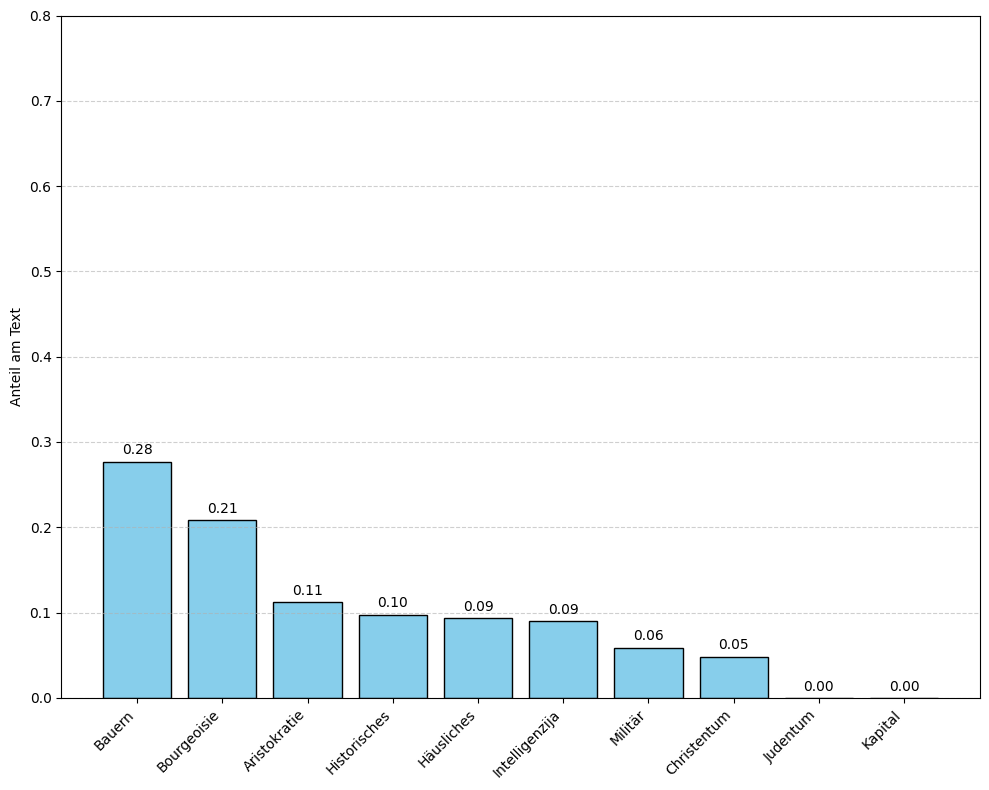

In [70]:
# top topics for Document "Marta"
topic_labels = [
    'Bourgeoisie',
    'Intelligenzija',
    'Aristokratie',
    'Häusliches',
    'Bauern',
    'Christentum',
    'Historisches',
    'Militär',
    'Judentum',
    'Kapital'
]

title = "Cham"

for i in range(len(titles)):
    if titles[i].startswith(title):
        topic_probs = vecs[i]

# ---- Ranking ----
sorted_indices = np.argsort(-topic_probs)
sorted_values = topic_probs[sorted_indices]
sorted_labels = [topic_labels[i] for i in sorted_indices]

print("Topic Ranking (Highest → Lowest):\n")
for rank, (label, value) in enumerate(zip(sorted_labels, sorted_values), start=1):
    print(f"{rank}. {label}: {value:.6f}")

# ---- Plot ----
plt.figure(figsize=(10,8))
plt.bar(range(len(sorted_values)), sorted_values, color="skyblue", edgecolor="black")

plt.ylabel("Anteil am Text")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 0.8)

# Optional: show values on top of bars
for i, val in enumerate(sorted_values):
    plt.text(i, val + 0.005, f"{val:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(prefix + "_" + title +"_topics.png", dpi=600)
plt.show()

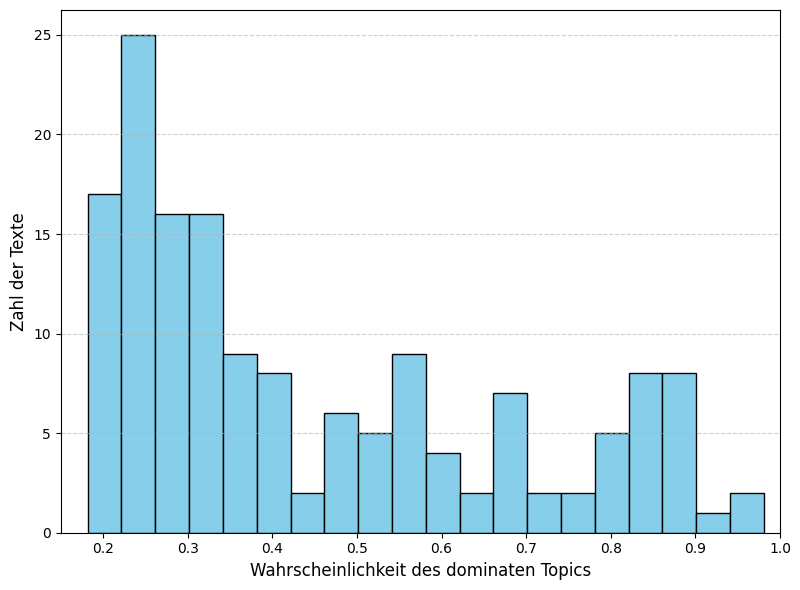

[0.29052696 0.32420203 0.50779033 0.42021045 0.3092688  0.86449206
 0.22862478 0.84170628 0.91682965 0.25133318 0.23514797 0.254269
 0.81739801 0.51280499 0.6137318  0.20296432 0.21267357 0.82601517
 0.26061016 0.568097   0.25144443 0.30422264 0.89162362 0.67378193
 0.24656834 0.27545771 0.23035876 0.28180507 0.25411293 0.23892637
 0.23886043 0.38341013 0.83976018 0.23881173 0.33960333 0.54723722
 0.21506914 0.3175914  0.96552396 0.62025553 0.38366354 0.88602328
 0.2346583  0.18162225 0.37767115 0.33403996 0.62634689 0.98095596
 0.19287419 0.38549224 0.27060735 0.32030028 0.85495847 0.24559301
 0.87110651 0.27409467 0.3060165  0.46392435 0.48045069 0.34983438
 0.80184966 0.28877598 0.29849672 0.87322491 0.50064641 0.19825879
 0.56777829 0.27690661 0.42027721 0.27727598 0.82746571 0.59322494
 0.38379163 0.57661331 0.68751574 0.69854116 0.18521406 0.36063483
 0.39242974 0.25393483 0.4253684  0.23355101 0.80002457 0.34364304
 0.24331115 0.20772567 0.67983991 0.35482702 0.23620884 0.289511

In [54]:
# dominant topics histo
import matplotlib.pyplot as plt

# dominant topic probability per text
dominant_probs = np.max(vecs, axis=1)

plt.figure(figsize=(8,6))
plt.hist(dominant_probs, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Wahrscheinlichkeit des dominaten Topics", fontsize=12)
plt.ylabel("Zahl der Texte", fontsize=12)
#plt.title("Monothematicity of Texts in Corpus", fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xlim(0.15, 1)
plt.savefig(prefix + "_dominant_topic_hist.png", dpi=600)
plt.show()
print(dominant_probs)


In [122]:
corpus_topic_distribution

array([0.16568041, 0.11727429, 0.17753209, 0.08841696, 0.14761943,
       0.06049931, 0.15157981, 0.03719785, 0.02659807, 0.02125968])

## Older stuff....

In [82]:
# new approach
from scipy.spatial.distance import pdist, squareform

def hellinger(u, v):
    """Hellinger distance between two probability vectors."""
    return np.sqrt(0.5 * np.sum((np.sqrt(u) - np.sqrt(v))**2))
           
"""Return dense topic distributions for each document."""
vecs = np.zeros((len(corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob

#from umap import UMAP
#coords = UMAP(n_components=2, n_neighbors=60, random_state=42).fit_transform(vecs)

#isomap = Isomap(n_neighbors=70, n_components=2)
#coords = isomap.fit_transform(vecs)

#tsne = TSNE(
#    n_components=2,
#    perplexity=20,
#    learning_rate="auto",
#    init="pca",
#    random_state=42
#)
#coords = tsne.fit_transform(vecs)

vecs_hell = np.sqrt(vecs)

clusters = np.argmax(vecs, axis=1)  # shape (n_docs,) DOMINANT TOPCIS

import umap

umap_model = umap.UMAP(
    n_neighbors=12,     # was: 25 ~15% of corpus → stable
    min_dist=0.25,      # was: 0.15 allows separation but keeps gradients
    n_components=2,
    metric="euclidean", # is hellinger for vecs_hell = np.sqrt(vecs) 
    random_state=42
)

coords = umap_model.fit_transform(vecs_hell)

#clusterer = hdbscan.HDBSCAN(
#    min_cluster_size=4,  # was 8
#    min_samples=2,       # was 4
#    metric=hellinger     # your callable
#)
#clusters = clusterer.fit_predict(vecs_hell)

#cluster blogs
#km = KMeans(n_clusters=12, random_state=5)
#clusters = km.fit_predict(vecs)

#centroids
centroids = []
labels = []

#for c in sorted(set(clusters)):
#    if c == -1:
#        continue
#    centroids.append(vecs[clusters == c].mean(axis=0))
#    labels.append(f"Cluster {c}")

#centroids_2d = umap_model.transform(centroids)

with open(prefix+"_coords.pkl", 'wb') as f:
    pickle.dump(coords, f)

dominant_topics = np.argmax(vecs, axis=1)
import plotly.express as px
import plotly.io as pio
fig = px.scatter(x=coords[:,0], y=coords[:,1],  hover_name=chunk_titles,color=clusters, size=lengths,  width=1200, height=1000, color_continuous_scale=px.colors.qualitative.Vivid)
pio.renderers.default = "browser"
fig.show()
#fig.write_html(prefix+".html")
#pio.write_image(fig, prefix+'.pdf', scale=6, width=1080, height=1080)

/home/ghowa/habil/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Opening in existing browser session.


## Plot it for print

ValueError: s must be a scalar, or float array-like with the same size as x and y

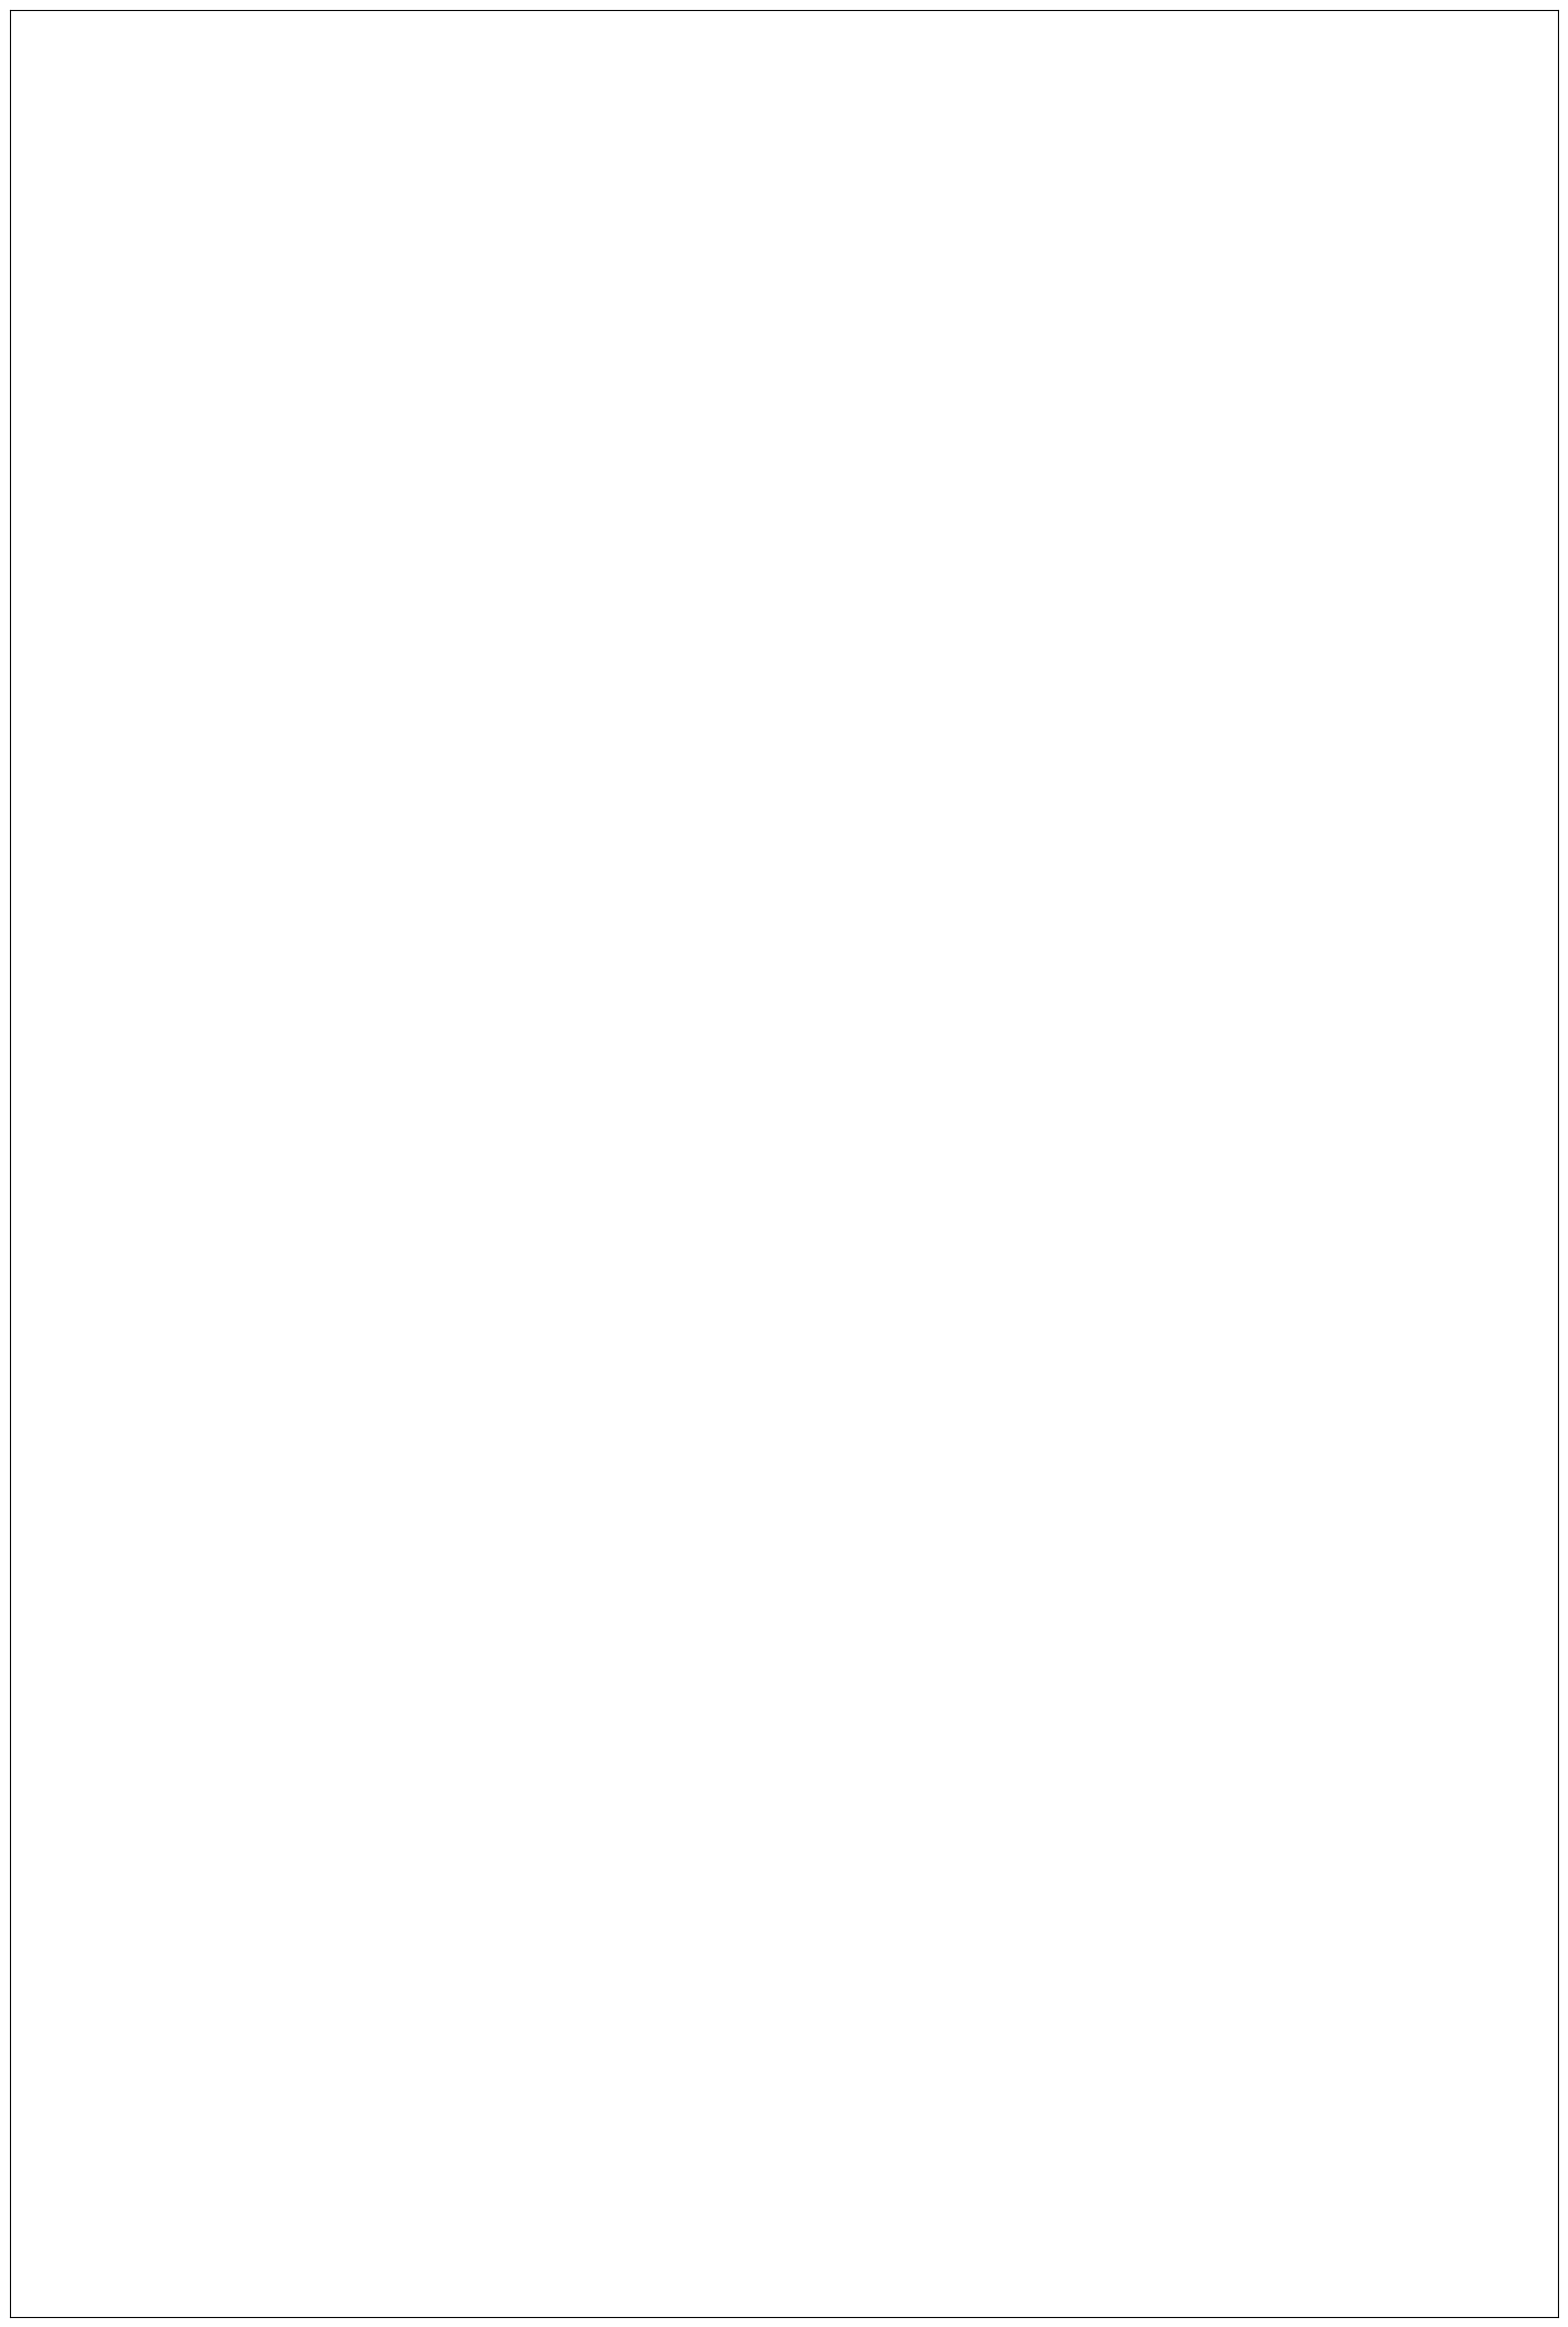

In [16]:
import re
from sklearn.metrics import silhouette_score

with open(prefix+'_coords.pkl', 'rb') as infile:
    coords2 = pickle.load(infile)

"""Return dense topic distributions for each document."""
vecs = np.zeros((len(corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob

import matplotlib.pyplot as plt
from adjustText import adjust_text

# fig + axes setup
fig, ax = plt.subplots(figsize=(20, 30))

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])

# scatter plot
from matplotlib.colors import ListedColormap

colors_15 = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
]

sc = ax.scatter(
    coords2[:, 0],
    coords2[:, 1],
    c=clusters,
    s=[l * 0.25 for l in lengths],
    cmap= colors_15,#get_cmap('tab20', 15),      # or 'tab20', etc.
    alpha=0.7,
   # edgecolors='k',
    linewidths=0.5
)

# add text labels
texts = []
for i in range(len(titles)):
    #if lengths[i] > 50:
    texts.append(ax.text(coords2[i, 0], coords2[i, 1], titles[i], fontsize=17))

# adjust text to avoid overlaps
adjust_text(
    texts,
    x=coords2[:, 0],
    y=coords2[:, 1],
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.33),
    expand_points=(1, 1),
    expand_text=(2, 2),
    force_text=.85,
    force_points=.4,
    lim=1000
)

# polish layout
#ax.grid(True, alpha=0.3)
plt.tight_layout()

# save to file
prefix = "scatter_plot"
plt.savefig(prefix + ".pdf", dpi=300, bbox_inches='tight')
plt.savefig(prefix + ".png", dpi=300, bbox_inches='tight')

# show plot
plt.show()

## 10 closest texts

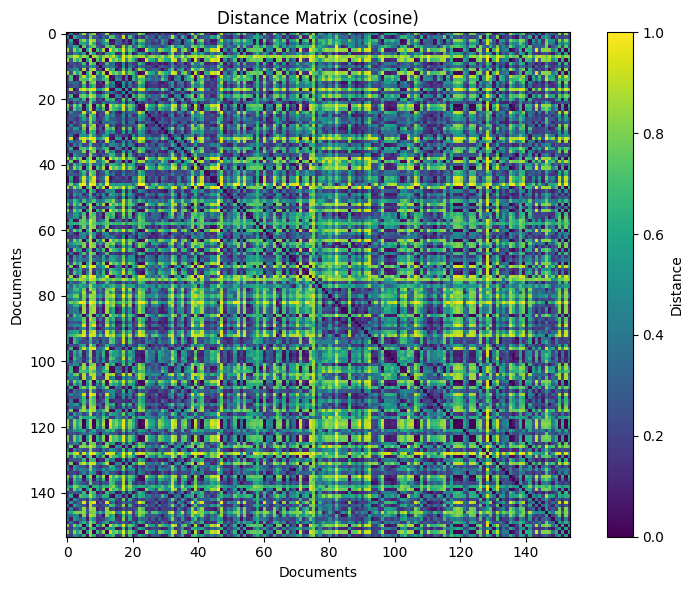

Dokument A..._B..._C..._1884_N.txt: ähnlichste = [('Jędza_1889_P.txt', np.int64(45)), ('Milord_1877_N.txt', np.int64(59)), ('Sylwek_Cmentarnik_1879_P.txt', np.int64(112)), ('Julianka_1877_N.txt', np.int64(44)), ('Dobra_pani_1882_N.txt', np.int64(28)), ('Zygmunt_Ławicz_i_jego_koledzy_1881_P.txt', np.int64(145)), ('Nad_Niemnem_1887_P.txt', np.int64(67)), ('Dziwak_1875_N.txt', np.int64(33)), ('Zefirek_1880_N.txt', np.int64(143)), ('Czternasta_część_1878_N.txt', np.int64(24))]
Dokument Ad_astra_Dwugłos_1902_P.txt: ähnlichste = [('Excelsior!_1897_N.txt', np.int64(37)), ('Pytanie_1887_N.txt', np.int64(99)), ('Wesele_Wiesiołka_1900_N.txt', np.int64(127)), ('Zrozpaczony_1890_N.txt', np.int64(144)), ('Wielki_1894_N.txt', np.int64(132)), ('Z_pomroku_1896_N.txt', np.int64(137)), ('Porcelanka_1898_N.txt', np.int64(93)), ('Liść_uschły_1897_N.txt', np.int64(53)), ('Zagadka_1899_N.txt', np.int64(142)), ('Posucha_1903_N.txt', np.int64(94))]
Dokument Anastazja_1900_P.txt: ähnlichste = [('Romanowa_1883_

In [84]:
# 10 closest texts
       
"""Return dense topic distributions for each document.
vecs = np.zeros((len(corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob
"""
from sklearn.metrics import pairwise_distances
# --- 1️⃣ Distanzmatrix berechnen ---
dist_matrix = pairwise_distances(vecs, metric="cosine")  # oder "euclidean"

# --- 2️⃣ Matrix plotten ---
plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix, cmap="viridis", interpolation="nearest")
plt.title("Distance Matrix (cosine)")
plt.colorbar(label="Distance")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- 1️⃣ Cosine Similarity berechnen ---
sim_matrix = cosine_similarity(vecs)

# --- 2️⃣ Für jeden Vektor die Top-10 ähnlichsten Indizes (ohne sich selbst) ---
top_k = 10
top_sim_indices = []

for i in range(sim_matrix.shape[0]):
    # argsort sortiert Indizes nach Ähnlichkeit (aufsteigend)
    # wir nehmen [-top_k-1:-1], um die 10 höchsten Werte zu kriegen (ohne das eigene Dokument)
    indices = np.argsort(sim_matrix[i])[-top_k-1:-1][::-1]
    try:
        top_sim_indices.append([(titles[ind], ind) for ind in indices])
    except IndexError:
        print(indices)

# Ausgabe
for i, indices in enumerate(top_sim_indices):
    print(f"Dokument {titles[i]}: ähnlichste = {indices}")

## Elbow plot

/tmp/ipykernel_99781/3952966336.py:13: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.



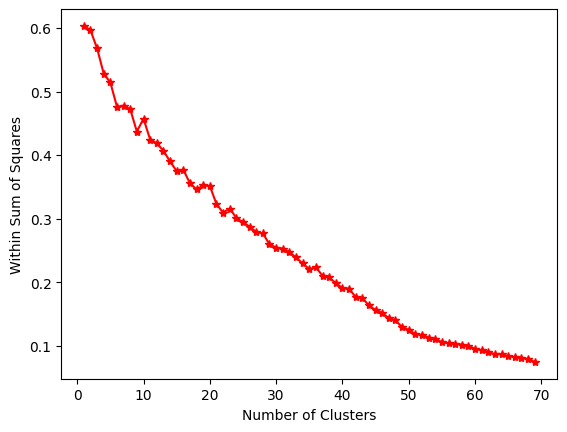

In [27]:
# estimate number of clusters
K = range(1,70)
KM = [KMeans(n_clusters=k).fit(vecs) for k in K]
centroids = [k.cluster_centers_ for k in KM]

D_k = [cdist(vecs, cent, 'euclidean') for cent in centroids]
dist = [np.min(D,axis=1) for D in D_k]
avgWithinSS = [sum(d)/vecs.shape[0] for d in dist]

# elbow curve
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(K, avgWithinSS, 'b*-', color='r')
plt.xlabel('Number of Clusters')
plt.ylabel(u'Within Sum of Squares')
plt.show()